### **Diabetes Dataset - II** 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
df = pd.read_csv('../dataset/supervised/diabetes[1].csv')
print(df.head())
print(df.info())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768

In [8]:
print("\nMean:\n", df.mean())
print("\nMedian:\n", df.median())
print("\nStandard Deviation:\n", df.std())


Mean:
 Pregnancies                   3.845052
Glucose                     120.894531
BloodPressure                69.105469
SkinThickness                20.536458
Insulin                      79.799479
BMI                          31.992578
DiabetesPedigreeFunction      0.471876
Age                          33.240885
Outcome                       0.348958
dtype: float64

Median:
 Pregnancies                   3.0000
Glucose                     117.0000
BloodPressure                72.0000
SkinThickness                23.0000
Insulin                      30.5000
BMI                          32.0000
DiabetesPedigreeFunction      0.3725
Age                          29.0000
Outcome                       0.0000
dtype: float64

Standard Deviation:
 Pregnancies                   3.369578
Glucose                      31.972618
BloodPressure                19.355807
SkinThickness                15.952218
Insulin                     115.244002
BMI                           7.884160
DiabetesPedi

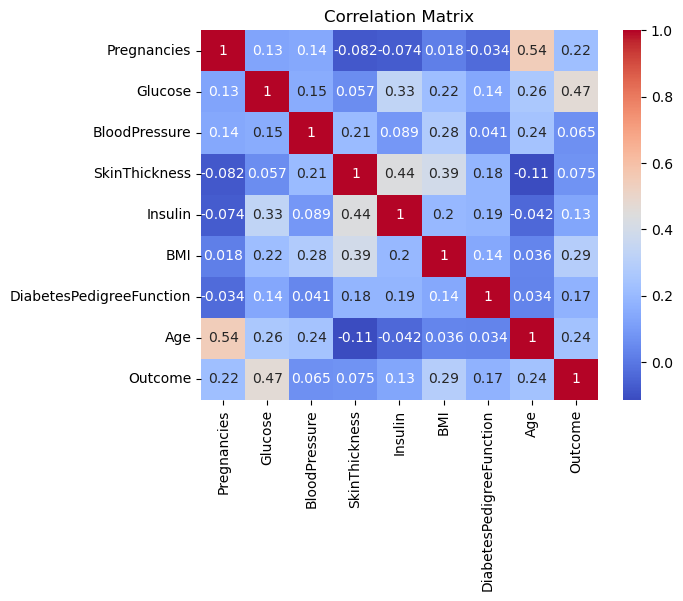

In [6]:
import seaborn as sns
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [9]:
X = df.iloc[:, :-1]   # features
y = df.iloc[:, -1]    # target

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [14]:
y_pred = model.predict(X_test)

In [15]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)
rmse = np.sqrt(mse)
print("RMSE:", rmse)

R2 Score: 0.2550028117674177
MSE: 0.171045272808501
RMSE: 0.41357619951890484


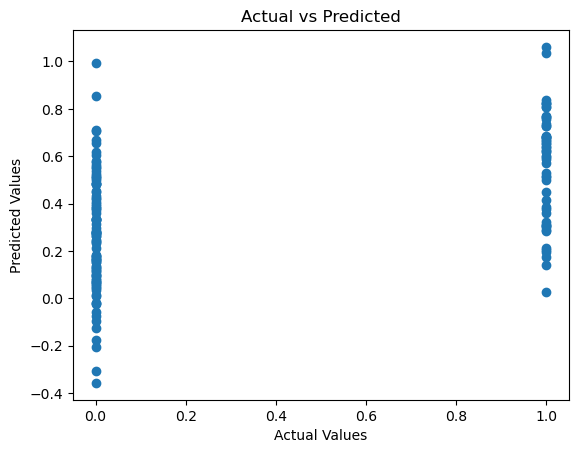

In [16]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

In [18]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: -0.9487546338208506
Coefficients: [ 0.01046818  0.00563353 -0.00228103  0.00053209 -0.00027815  0.01503864
  0.11126264  0.00646027]


## QUESTIONS

### Q1: Define Linear Regression.

Linear regression is a supervised learning algorithm used to model the relationship between a dependent variable (Y) and one or more independent variables (X) using a linear equation.

---

### Q2: Differentiate between Simple Linear Regression and Multiple Linear Regression.

#### Simple Linear Regression
- Uses only one independent variable
- Equation: Y = β0 + β1X + ε

#### Multiple Linear Regression
- Uses two or more independent variables
- Equation: Y = β0 + β1X1 + β2X2 + ... + βnXn + ε

#### Difference

| Aspect | Simple Linear Regression | Multiple Linear Regression |
|--------|--------------------------|----------------------------|
| Features | 1 | 2 or more |
| Complexity | Low | Higher |
| Usage | Limited | More practical |

---

### Q3: Write the mathematical equation of Linear Regression model.

Y = β0 + β1X1 + β2X2 + ... + βnXn + ε

Where:
- Y = dependent variable  
- X = independent variables  
- β0 = intercept  
- β1, β2, ..., βn = coefficients  
- ε = error term  

---

### Q4: What is the difference between R² and Adjusted R²?

#### R² (Coefficient of Determination)
- Measures how well the model explains variance
- Range: 0 to 1
- Always increases when more features are added

Formula:
R² = 1 - (SSres / SStot)

---

#### Adjusted R²
- Penalizes unnecessary features

Formula:
Adjusted R² = 1 - ((1 - R²)(n - 1) / (n - k - 1))

---

#### Difference

| Metric | Behavior |
|--------|----------|
| R² | Always increases with more features |
| Adjusted R² | Increases only if model improves |

---

### Q5: What is the difference between MSE and RMSE?

#### Mean Squared Error (MSE)

MSE = (1/n) * Σ(Yi - Ŷi)²

- Measures average squared error
- Unit is squared

---

#### Root Mean Squared Error (RMSE)

RMSE = √MSE

- Unit same as target variable
- Easier to interpret

---

#### Difference

| Metric | MSE | RMSE |
|--------|-----|------|
| Unit | Squared | Same as output |
| Interpretation | Less intuitive | More intuitive |
| Sensitivity to outliers | High | High |